In [3]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 35.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import time
import pickle

In [51]:
fn_NN = '../../Active_SAM_joined/SAM_DR_v5nounlabeled_NONneuron_geneexp_09062026.h5ad'
sam_NN = SAM()
sam_NN.load_data(fn_NN)

In [52]:
fn = '../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad'
sam = SAM()
sam.load_data(fn)

In [53]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass',
       'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'ss_subclass', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_v4_nn_thresh30',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3',
       'yanay_labels', 'yanay_label_nounlabeled', 'ss_subclass_old',
       'ss_subclass_v5_nounlabeled', 'ss_subclass_v5_nounlabeled_nn',
       'ss_subclass_nounlabeled_nmm_v5_nn',
       'ss_subclass_nounlabeled_nmm_cl_v5_nn'],
      dtype='object')

In [54]:
sm = load_samap('../../Active_SAMap_Joined/sm_Allen_nonneural2000_dr_NONneuron_090720206.pkl')

In [55]:
org_one = 'mg'
org_two = 'dr'

In [56]:
sm.sams[org_two].adata.obs_names.equals(sam_NN.adata.obs_names)

True

In [57]:
sm.sams[org_two].clustering(param = 2)

In [58]:
level_one = 'subclass_id_label'
level_two = 'leiden_clusters'

In [59]:
keys = {org_one:level_one,org_two:level_two}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable =  MappingTable.loc[:,[i for i in MappingTable.columns if i[:2] == org_one]]
lim_MappingTable = lim_MappingTable.loc[[i for i in lim_MappingTable.index if i[:2] == org_two],:]

In [11]:
df = pd.read_csv('../../OTO_star_nothreshold_missing_le2_expressionthresh_08022026.tsv',delimiter='\t', index_col = 'Unnamed: 0')

In [12]:
df.loc[df.index[np.where(df['MM'] == 'Gfap')],:]

,MM,MO,CJ,AC,XT,DR
49511@7742,Gfap,Gfap,GFAP,gfap,NaN,gfap


In [60]:
new_mapping = {}
for item in lim_MappingTable.index:
    if np.max(lim_MappingTable.loc[item,:]) > .2 and len(sm.sams[org_two].adata[sm.sams[org_two].adata.obs[level_two] == int(item[3:])]) > 25:
        new_mapping[item] = lim_MappingTable.loc[item,:].idxmax()[3:]
        if np.max(lim_MappingTable.loc[item,:])/lim_MappingTable.loc[item,:].nlargest(2).iloc[-1] < 2 and np.max(lim_MappingTable.loc[item,:]) - lim_MappingTable.loc[item,:].nlargest(2).iloc[-1] < 0.2:
            print(item,lim_MappingTable.loc[item,:].idxmax())
    else:
        print('Unmapped ' + item, len(sm.sams[org_two].adata[sm.sams[org_two].adata.obs['leiden_clusters'] == int(item[3:])]))

dr_1 mg_319 Astro-TE NN
Unmapped dr_19 262
dr_2 mg_335 BAM NN
Unmapped dr_20 258
Unmapped dr_21 256
Unmapped dr_22 229
Unmapped dr_24 205
dr_25 mg_331 Peri NN
Unmapped dr_26 199
dr_31 mg_337 DC NN
Unmapped dr_33 120
Unmapped dr_34 86
Unmapped dr_36 84
Unmapped dr_38 46
dr_5 mg_319 Astro-TE NN


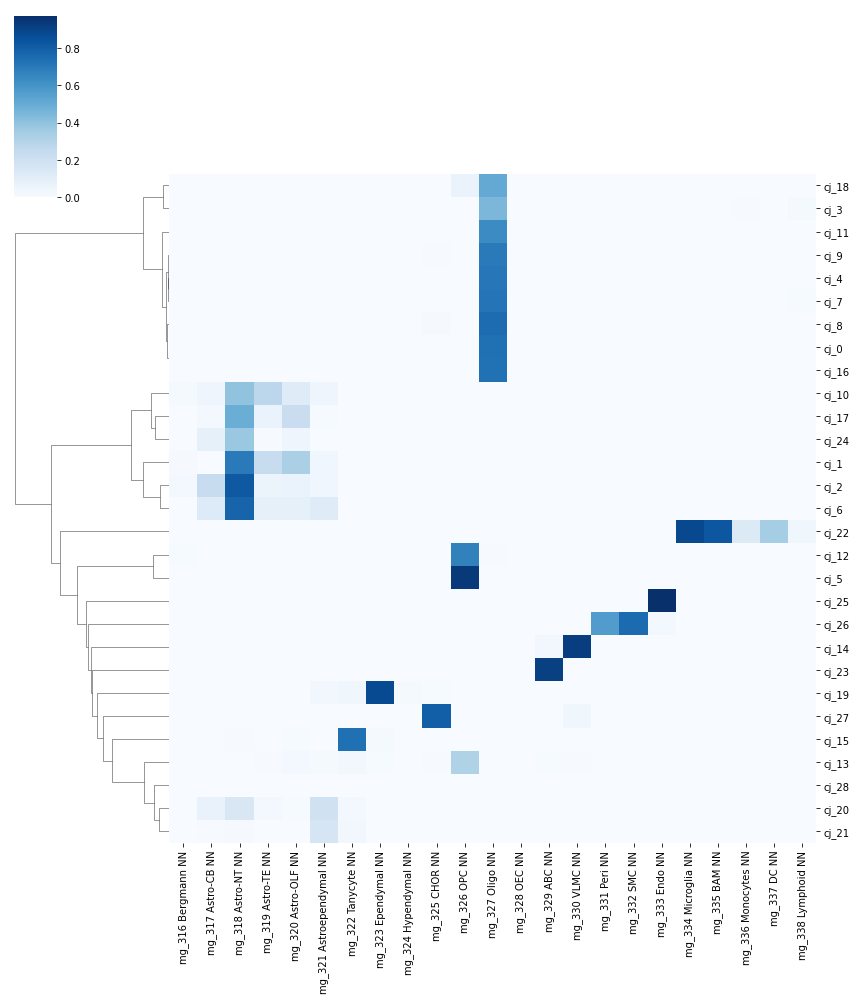

In [111]:
g = sns.clustermap(lim_MappingTable, col_cluster = False, method = 'ward', cmap = 'Blues',figsize = (12,14))
row_order = g.dendrogram_row.reordered_ind 

In [12]:
row_ord_plt = [int(i[3:]) for i in lim_MappingTable.index[row_order]]

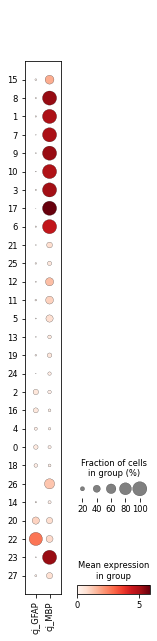

In [16]:
sc.pl.dotplot(sm.sams[org_two].adata, ['cj_GFAP','cj_MBP'], groupby = 'leiden_clusters', categories_order=row_ord_plt)

In [81]:
new_mapping

{'ac_0': '318 Astro-NT NN',
 'ac_1': '327 Oligo NN',
 'ac_10': '330 VLMC NN',
 'ac_11': '327 Oligo NN',
 'ac_12': '327 Oligo NN',
 'ac_13': '326 OPC NN',
 'ac_14': '320 Astro-OLF NN',
 'ac_15': '321 Astroependymal NN',
 'ac_16': '326 OPC NN',
 'ac_17': '322 Tanycyte NN',
 'ac_18': '330 VLMC NN',
 'ac_19': '335 BAM NN',
 'ac_2': '327 Oligo NN',
 'ac_21': '327 Oligo NN',
 'ac_22': '333 Endo NN',
 'ac_23': '338 Lymphoid NN',
 'ac_24': '329 ABC NN',
 'ac_3': '326 OPC NN',
 'ac_4': '327 Oligo NN',
 'ac_5': '334 Microglia NN',
 'ac_6': '327 Oligo NN',
 'ac_7': '327 Oligo NN',
 'ac_8': '327 Oligo NN',
 'ac_9': '324 Hypendymal NN'}

In [112]:
lim_MappingTable.columns

Index(['mg_316 Bergmann NN', 'mg_317 Astro-CB NN', 'mg_318 Astro-NT NN',
       'mg_319 Astro-TE NN', 'mg_320 Astro-OLF NN', 'mg_321 Astroependymal NN',
       'mg_322 Tanycyte NN', 'mg_323 Ependymal NN', 'mg_324 Hypendymal NN',
       'mg_325 CHOR NN', 'mg_326 OPC NN', 'mg_327 Oligo NN', 'mg_328 OEC NN',
       'mg_329 ABC NN', 'mg_330 VLMC NN', 'mg_331 Peri NN', 'mg_332 SMC NN',
       'mg_333 Endo NN', 'mg_334 Microglia NN', 'mg_335 BAM NN',
       'mg_336 Monocytes NN', 'mg_337 DC NN', 'mg_338 Lymphoid NN'],
      dtype='object')

In [12]:
#Mapping CJ
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [19]:
sam_NN.adata.obs['test'] = fin_mapping
sam_NN.adata.obs['test'] = sam_NN.adata.obs['test'].astype('category')
sam_NN.adata.obs['test'].equals(sam_NN.adata.obs['ss_subclass_v5_nounlabeled_nn'])

True

In [32]:
#Mapping AC
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [33]:
sam_NN.adata.obs['test'] = fin_mapping
sam_NN.adata.obs['test'] = sam_NN.adata.obs['test'].astype('category')
sam_NN.adata.obs['test'].equals(sam_NN.adata.obs['ss_subclass_v5_nounlabeled_nn'])

True

In [47]:
#Mapping XT
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [48]:
sam_NN.adata.obs['test'] = fin_mapping
sam_NN.adata.obs['test'] = sam_NN.adata.obs['test'].astype('category')
sam_NN.adata.obs['test'].equals(sam_NN.adata.obs['ss_subclass_v5_nounlabeled_nn'])

True

In [61]:
#Mapping DR
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [62]:
sam_NN.adata.obs['test'] = fin_mapping
sam_NN.adata.obs['test'] = sam_NN.adata.obs['test'].astype('category')
sam_NN.adata.obs['test'].equals(sam_NN.adata.obs['ss_subclass_v5_nounlabeled_nn'])

True

In [114]:
sm.sams[org_two].adata.obs['ss_subclass_v5_nounlabeled_nn'] = fin_mapping
sm.sams[org_two].adata.obs['leiden_clusters_nonneuron'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [115]:
sam_NN.adata.obs['ss_subclass_v5_nounlabeled_nn'] = fin_mapping
sam_NN.adata.obs['leiden_clusters_nonneuron'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [116]:
np.sort(sm.sams[org_two].adata.obs['ss_subclass_v5_nounlabeled_nn'].unique())

array(['322 Tanycyte NN', '323 Ependymal NN', '325 CHOR NN', '326 OPC NN',
       '327 Oligo NN', '329 ABC NN', '330 VLMC NN', '332 SMC NN',
       '333 Endo NN', '339 Astrocyte-like NN', '340 Macrophage NN',
       'Unlabeled'], dtype=object)

In [117]:
np.sort(sam_NN.adata.obs['ss_subclass_v5_nounlabeled_nn'].unique())

array(['322 Tanycyte NN', '323 Ependymal NN', '325 CHOR NN', '326 OPC NN',
       '327 Oligo NN', '329 ABC NN', '330 VLMC NN', '332 SMC NN',
       '333 Endo NN', '339 Astrocyte-like NN', '340 Macrophage NN',
       'Unlabeled'], dtype=object)

In [118]:
sm.sams[org_two].adata.X

<18966x20032 sparse matrix of type '<class 'numpy.float32'>'
	with 13965653 stored elements in Compressed Sparse Row format>

In [119]:
sam_NN.adata.X

<18966x20032 sparse matrix of type '<class 'numpy.float32'>'
	with 13965653 stored elements in Compressed Sparse Row format>

In [63]:
fin_labels = []
for item in sam.adata.obs_names:
    if item in sm.sams[org_two].adata.obs_names:
        fin_labels.append(sm.sams[org_two].adata.obs.loc[item,'ss_subclass_v5_nounlabeled_nn'])
    else:
        fin_labels.append(sam.adata.obs.loc[item,'ss_subclass_v5_nounlabeled'])
fin_labels = pd.Series(fin_labels, index=sam.adata.obs_names)
sam.adata.obs['test'] = fin_labels

In [64]:
sam.adata.obs['test'] = sam.adata.obs['test'].astype('category')
sam.adata.obs['test'].equals(sam.adata.obs['ss_subclass_v5_nounlabeled_nn'])

True

In [121]:
np.sort(sam.adata.obs['ss_subclass_v5_nounlabeled_nn'].unique())

array(['004 L6 IT CTX Glut', '006 L4/5 IT CTX Glut',
       '007 L2/3 IT CTX Glut', '014 LA-BLA-BMA-PA Glut', '017 CA3 Glut',
       '041 OB-in Frmd7 Gaba', '049 Lamp5 Gaba', '052 Pvalb Gaba',
       '053 Sst Gaba', '054 STR Prox1 Lhx6 Gaba', '055 STR Lhx8 Gaba',
       '057 NDB-SI-MA-STRv Lhx8 Gaba', '058 PAL-STR Gaba-Chol',
       '061 STR D1 Gaba', '062 STR D2 Gaba', '063 STR D1 Sema5a Gaba',
       '064 STR-PAL Chst9 Gaba', '066 NDB-SI-ant Prdm12 Gaba',
       '068 LSX Otx2 Gaba', '069 LSX Nkx2-1 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '074 MEA-BST Lhx6 Sp9 Gaba',
       '076 MEA-BST Lhx6 Nfib Gaba', '077 CEA-BST Gal Avp Gaba',
       '081 ACB-BST-FS D1 Gaba', '082 CEA-BST Ebf1 Pdyn Gaba',
       '084 BST-SI-AAA Six3 Slc22a3 Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '088 BST Tac2 Gaba',
       '089 PVR Six3 Sox3 Gaba', '090 BST-MPN Six3 Nrgn Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '097 PVHd-SB

In [122]:
sam.adata

AnnData object with n_obs × n_vars = 74758 × 20032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts', 'key', 'hicat_merged', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match', 'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed', 'ss_subclass_nounlabeled_nmm_v2', 'subclass_id_label_crossed_NN

In [123]:
set(sam.adata.obs['ss_subclass_v5_nounlabeled'].unique()) - set(sam.adata.obs['ss_subclass_v5_nounlabeled_nn'].unique())

{'319 Astro-TE NN',
 '321 Astroependymal NN',
 '334 Microglia NN',
 'cj_0',
 'cj_14',
 'cj_26'}

In [124]:
print(fn,fn_NN)

../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad ../../Active_SAM_joined/SAM_CJ_v5nounlabeled_NONneuron_geneexp_09062026.h5ad


In [125]:
print(sam_NN.adata.obs['ss_subclass_v5_nounlabeled_nn'].isna().sum())

0


In [126]:
print(sm.sams[org_two].adata.obs['ss_subclass_v5_nounlabeled_nn'].isna().sum())

0


In [127]:
print(sam.adata.obs['ss_subclass_v5_nounlabeled_nn'].isna().sum())

0


In [128]:
save_samap(sm,'../../Active_SAMap_Joined/sm_Allen_nonneural2000_dr_NONneuron_090720206.pkl')

In [129]:
sam.save_anndata(fn)

In [130]:
sam_NN.save_anndata(fn_NN)